In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
users=pd.read_csv(r"D:\Data_Analytics\Projects\churn-behaviour-analysis\data\users.csv")
features=pd.read_csv(r"D:\Data_Analytics\Projects\churn-behaviour-analysis\data\features.csv")
feature_usage=pd.read_csv(r"D:\Data_Analytics\Projects\churn-behaviour-analysis\data\feature_usage.csv")
subscription=pd.read_csv(r"D:\Data_Analytics\Projects\churn-behaviour-analysis\data\subscription.csv")
sessions=pd.read_csv(r"D:\Data_Analytics\Projects\churn-behaviour-analysis\data\sessions.csv")
churn_status=pd.read_csv(r"D:\Data_Analytics\Projects\churn-behaviour-analysis\data\churn_status.csv")

In [71]:
df_users=users.copy()
df_features=features.copy()
df_feature_usage=feature_usage.copy()
df_subscription=subscription.copy()
df_sessions=sessions.copy()
df_churn_status=churn_status.copy()

In [72]:
df_users.shape #17 rows and 6 cols

(17, 6)

In [73]:
df_churn_status.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       17 non-null     int64  
 1   churn_status  17 non-null     int64  
 2   churn_date    6 non-null      object 
 3   user_rating   17 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 676.0+ bytes


In [74]:
df_churn_status['user_rating'].describe()

count    17.000000
mean      3.600000
std       1.126943
min       1.800000
25%       2.500000
50%       3.900000
75%       4.600000
max       5.000000
Name: user_rating, dtype: float64

In [75]:
df_churn_status.isnull().sum()

user_id          0
churn_status     0
churn_date      11
user_rating      0
dtype: int64

In [76]:
df_churn_status[df_churn_status['churn_date'].isnull()] 

,user_id,churn_status,churn_date,user_rating
0,101,0,NaN,4.9
1,102,0,NaN,4.0
2,103,0,NaN,4.2
3,105,0,NaN,3.9
5,107,0,NaN,3.8
6,108,0,NaN,4.7
7,109,0,NaN,4.8
10,112,0,NaN,4.6
12,114,0,NaN,5.0
13,115,0,NaN,4.1


### These are active users, hence there is no churn date for them

<Axes: ylabel='user_rating'>

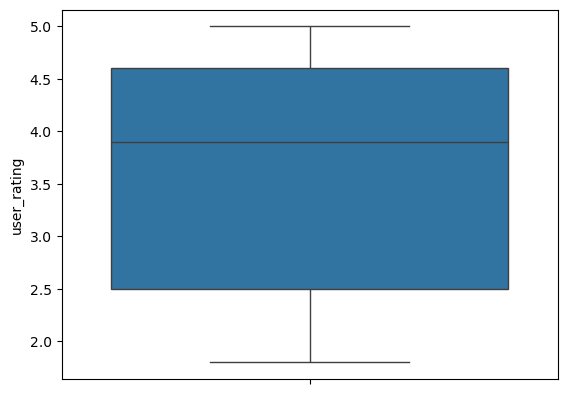

In [77]:
sns.boxplot(df_churn_status['user_rating'])  

### There is no outliers in this

In [78]:
df_churn_status['churn_status'].value_counts()

churn_status
0    11
1     6
Name: count, dtype: int64

### We can see there are 11 active users and 6 churned users

In [79]:
df_churn_status['churn_date']=pd.to_datetime(df_churn_status['churn_date'])

In [80]:
df_churn_status['churn_date'].dtype

dtype('<M8[ns]')

In [81]:
df_churn_status['churn_date']

0           NaT
1           NaT
2           NaT
3           NaT
4    2025-05-02
5           NaT
6           NaT
7           NaT
8    2024-10-01
9    2026-05-01
10          NaT
11   2026-05-20
12          NaT
13          NaT
14   2021-02-02
15   2026-03-15
16          NaT
Name: churn_date, dtype: datetime64[ns]

# UNIVARIATE ANALYSIS

In [82]:
df_users.columns

Index(['user_id', 'user_name', 'contact_info', 'sign_up_date',
       'subscription_type', 'country'],
      dtype='object')

In [83]:
df_users['sign_up_date']=pd.to_datetime(df_users['sign_up_date'])
df_users['sign_up_month']=df_users['sign_up_date'].dt.to_period('M')
monthly_signups = df_users.groupby('sign_up_month').size().reset_index(name='count')

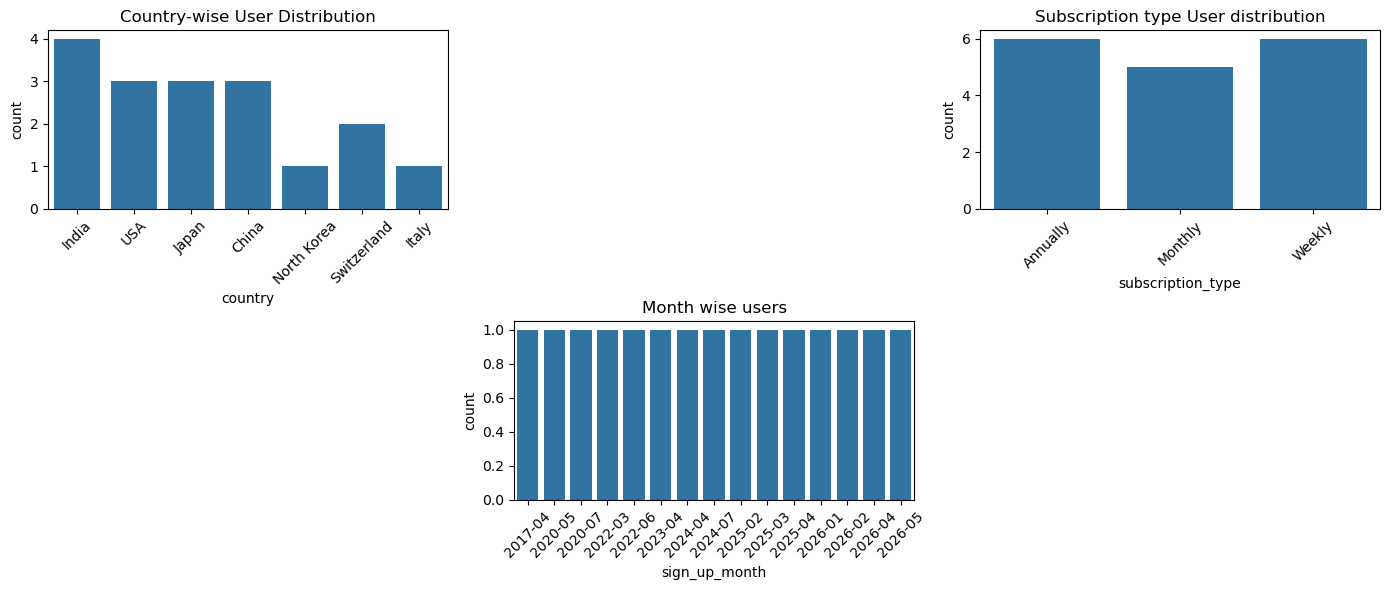

In [84]:
plt.figure(figsize=(14,6))

plt.subplot(2,3,1)
sns.countplot(data=df_users,x='country')
plt.title('Country-wise User Distribution')
plt.xticks(rotation=45)

plt.subplot(2,3,3)
sns.countplot(data=df_users,x='subscription_type')
plt.title('Subscription type User distribution')
plt.xticks(rotation=45)

plt.subplot(2,3,5)
sns.countplot(data=monthly_signups,x='sign_up_month')
plt.title('Month wise users')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [86]:
df_subscription.columns

Index(['subscription_id', 'user_id', 'subscription_time', 'plan_name',
       'amount'],
      dtype='object')

In [87]:
df_subscription['subscription_time']=pd.to_datetime(df_subscription['subscription_time'])

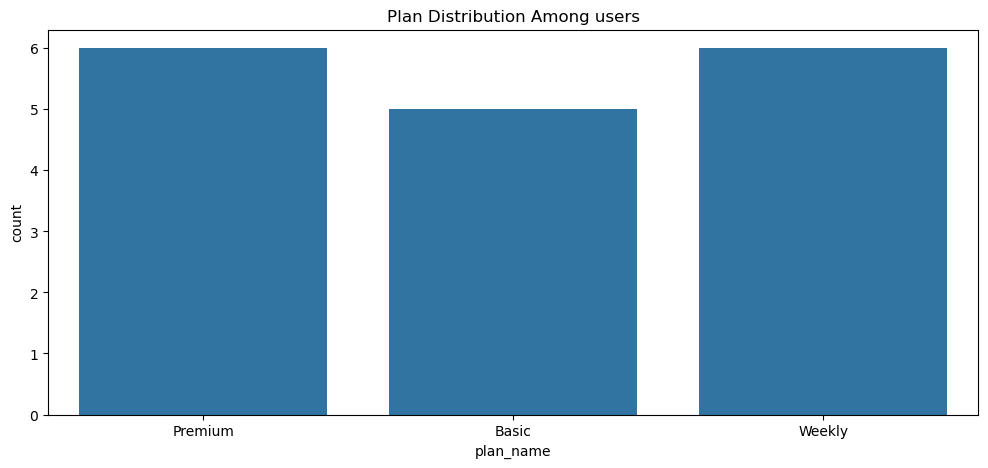

In [88]:
plt.figure(figsize=(12,5))
plt.subplot(1,1,1)
sns.countplot(data=df_subscription,x='plan_name')
plt.title("Plan Distribution Among users")
plt.show()

Text(0.5, 1.0, 'Average Revenue by Plan')

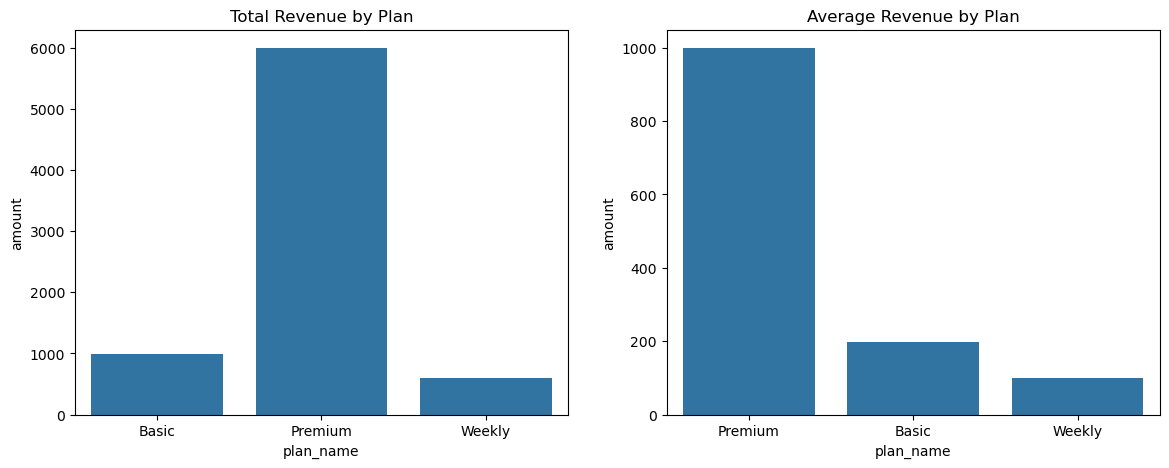

In [89]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
revenue=df_subscription.groupby('plan_name')['amount'].sum().reset_index()
sns.barplot(data=revenue,x='plan_name',y='amount')
plt.title('Total Revenue by Plan')

plt.subplot(1,2,2)
sns.barplot(data=df_subscription,x='plan_name',y='amount')
plt.title('Average Revenue by Plan')

Text(0.5, 1.0, 'Subscription Trend over time')

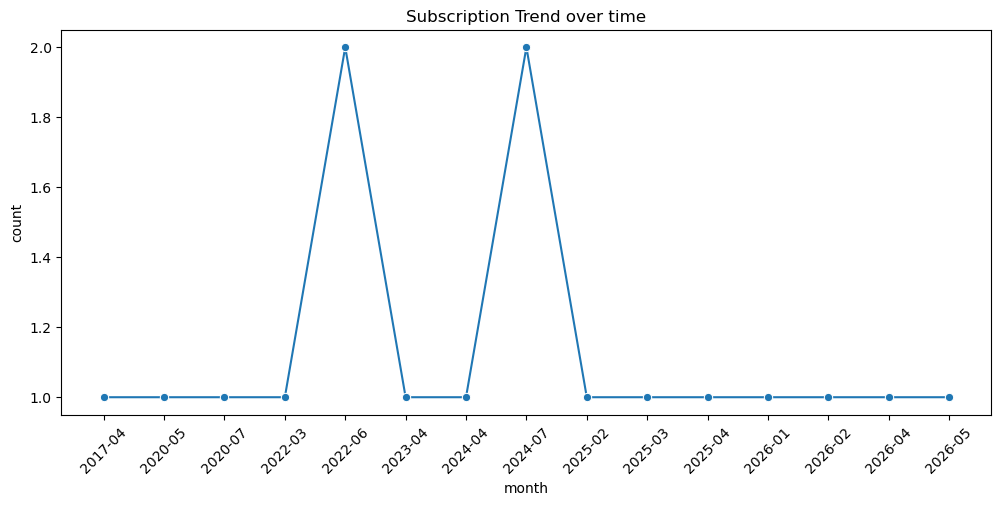

In [90]:
df_subscription['month']=df_subscription['subscription_time'].dt.to_period('M')
monthly=df_subscription.groupby('month').size().reset_index(name='count')
monthly['month']=monthly['month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly,x='month',y='count',marker='o')
plt.xticks(rotation=45)
plt.title('Subscription Trend over time')


Text(0.5, 1.0, 'Revenue Trend over Time')

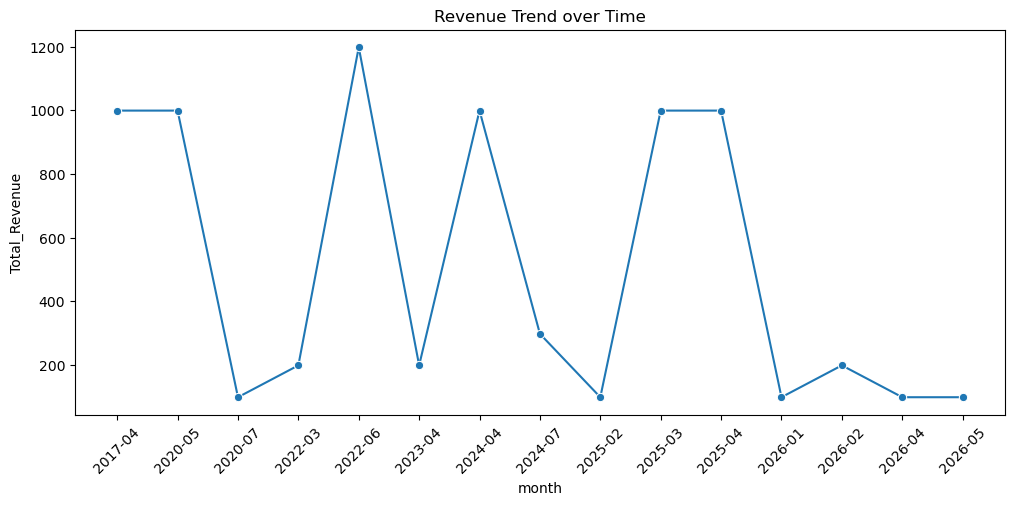

In [91]:
revenue_2=df_subscription.groupby('month')['amount'].sum().reset_index(name='Total_Revenue')
revenue_2['month']=revenue_2['month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=revenue_2,x='month',y='Total_Revenue',marker='o')
plt.xticks(rotation=45)
plt.title('Revenue Trend over Time')

In [92]:
df_sessions.columns

Index(['session_id', 'user_id', 'log_in_time', 'log_out_time'], dtype='object')

In [93]:
df_sessions['log_in_time']=pd.to_datetime(df_sessions['log_in_time'])
df_sessions['log_out_time']=pd.to_datetime(df_sessions['log_out_time'])
df_sessions['session_duration']=df_sessions['log_out_time']-df_sessions['log_in_time']

In [94]:
df_sessions['session_duration']=df_sessions['session_duration'].dt.total_seconds()/60


In [95]:
user_Duration=df_sessions.groupby('user_id')['session_duration'].sum().reset_index(name='Duration')
user_Duration_top=user_Duration.sort_values(by='Duration',ascending=False)

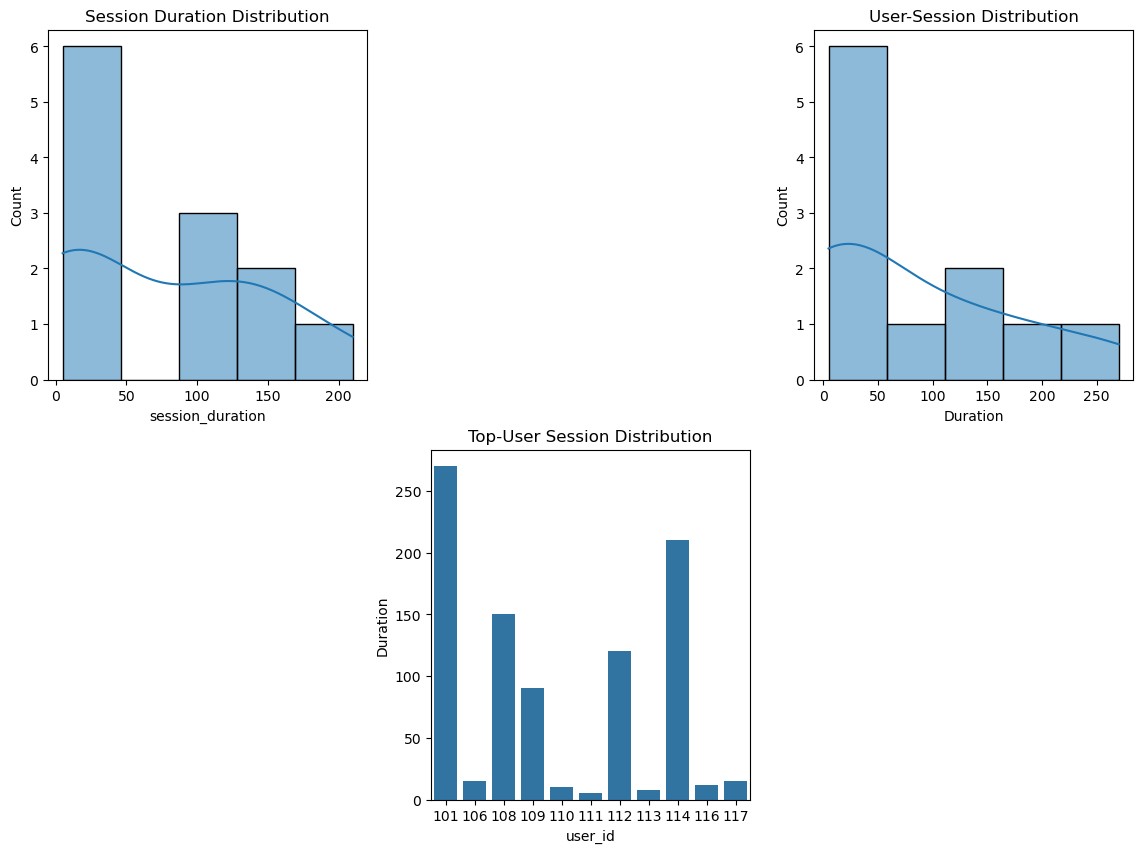

In [96]:
plt.figure(figsize=(14,10))

plt.subplot(2,3,1)
sns.histplot(data=df_sessions,x='session_duration',bins=5,kde=True)
plt.title('Session Duration Distribution')

plt.subplot(2,3,3)
sns.histplot(data=user_Duration,x='Duration',bins=5,kde=True)
plt.title('User-Session Distribution')

plt.subplot(2,3,5)
sns.barplot(data=user_Duration_top,x='user_id',y='Duration')
plt.title('Top-User Session Distribution')
plt.show()


Most session records duration lesser than 50 mins,while a few only exceeds 100 mins indicating short-to-moderate sessions are more common than longer sessions 

Most users accumulated duration of lesser than 50 minutes while small number of users accumalated duration more than 100 mins on the platform

User_id=101 has used the platform more than others

Text(0.5, 1.0, 'Average Session Duration per user')

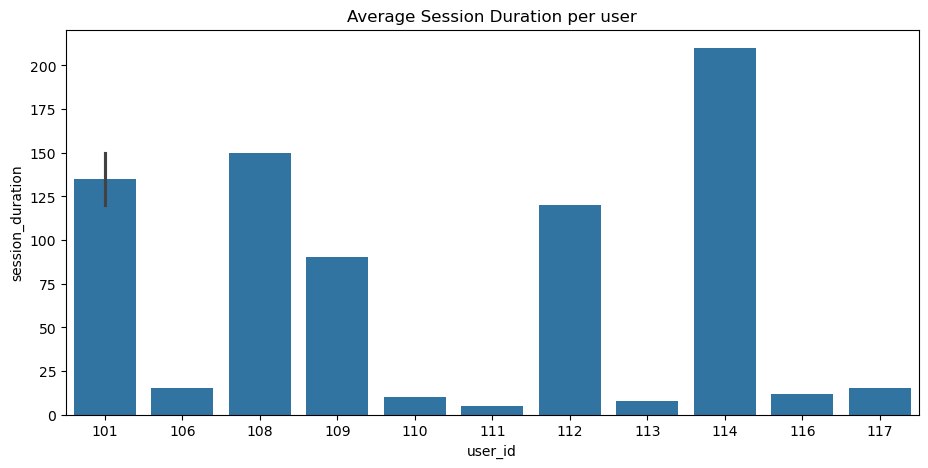

In [97]:
plt.figure(figsize=(11,5))
sns.barplot(data=df_sessions,x='user_id',y='session_duration')
plt.title('Average Session Duration per user')

User_id=114 has the highest average Session duration 

In [100]:
df_feature_usage.columns

Index(['usage_id', 'feature_id', 'user_id', 'usage_time'], dtype='object')

In [101]:
df_feature_usage['usage_time']=pd.to_datetime(df_feature_usage['usage_time'])

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_19352\2062179336.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_feature_usage['usage_time']=pd.to_datetime(df_feature_usage['usage_time'])


In [102]:
feature_data=pd.merge(df_feature_usage,df_features,on='feature_id',how='left')

In [103]:
feature_data

,usage_id,feature_id,user_id,usage_time,feature_name,feature_date_time
0,1,10,101,2026-06-04 09:20:00,Daily Streaks,2023-07-02 16:30:00.000
1,2,1,101,2026-06-04 10:15:00,AI Assistant,2022-03-12 14:30:00.000
2,3,11,101,2026-06-04 10:40:00,Create Notes,2022-04-03 11:00:00.000
3,4,10,108,2026-06-04 08:45:00,Daily Streaks,2023-07-02 16:30:00.000
4,5,3,108,2026-06-04 09:10:00,AI Test Paper Analyzer,2024-03-03 16:30:00.000
5,6,1,109,2026-06-04 10:00:00,AI Assistant,2022-03-12 14:30:00.000
6,7,10,109,2026-06-04 10:45:00,Daily Streaks,2023-07-02 16:30:00.000
7,8,1,112,2026-06-04 07:30:00,AI Assistant,2022-03-12 14:30:00.000
8,9,2,112,2026-06-04 08:20:00,AI Transcript,2023-01-01 00:05:00.000
9,10,10,114,2026-06-04 09:00:00,Daily Streaks,2023-07-02 16:30:00.000


In [104]:
most_used_features=feature_data.groupby('feature_name').size().reset_index(name='Num of users using feature')
feature_with_unique_users=feature_data.groupby('feature_name')['user_id'].nunique().reset_index(name='Num of unique users using feature')

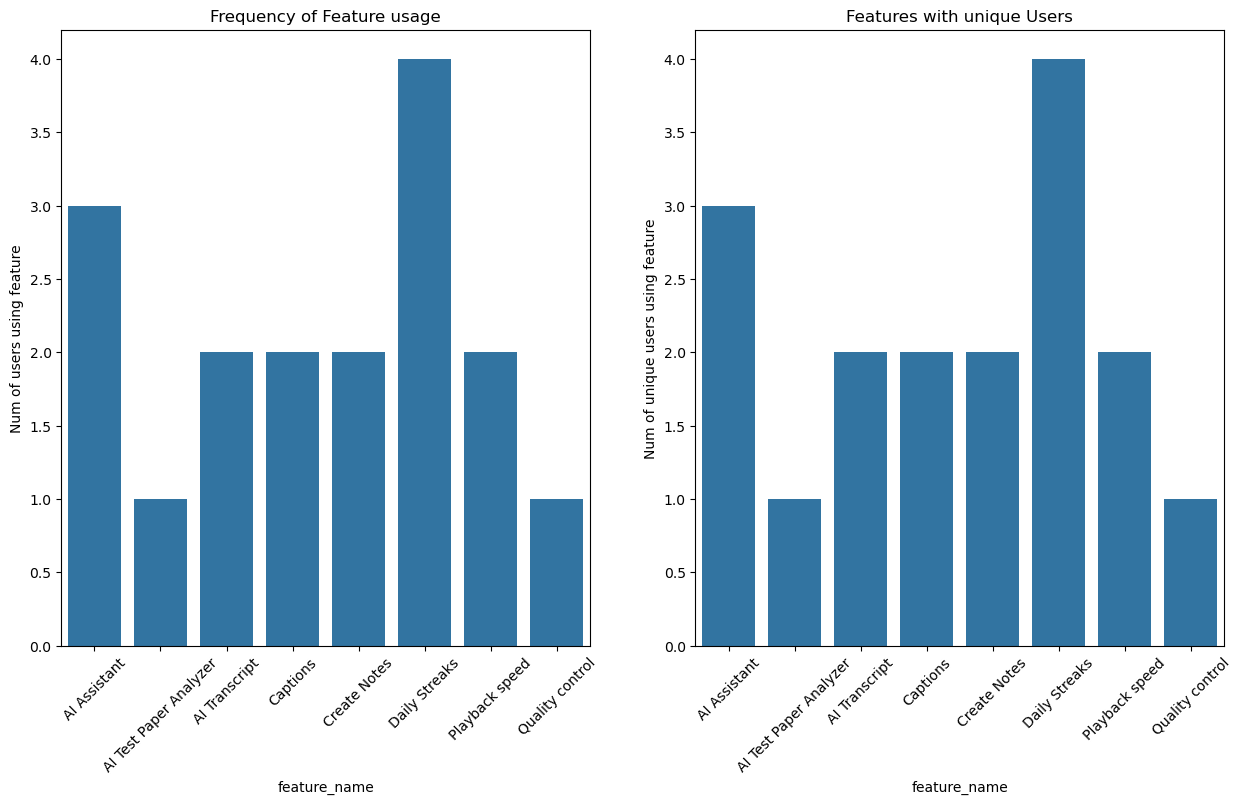

In [105]:
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
sns.barplot(data=most_used_features,x='feature_name',y='Num of users using feature')
plt.xticks(rotation=45)
plt.title('Frequency of Feature usage')

plt.subplot(1,2,2)
sns.barplot(data=feature_with_unique_users,x='feature_name',y='Num of unique users using feature')
plt.xticks(rotation=45)
plt.title('Features with unique Users')
plt.show()

Daily Streaks is most popular feature among users as well as the feature with most unique users followed by AI assistant

In [106]:
feature_used_each_user=feature_data.groupby('user_id')['feature_name'].nunique().reset_index(name='Num of Uniques features used by users')

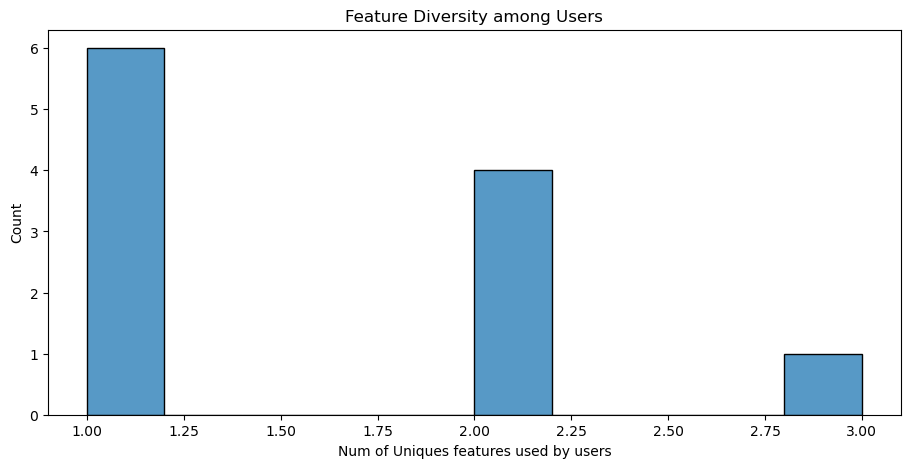

In [107]:
plt.figure(figsize=(11,5))

sns.histplot(data=feature_used_each_user,x='Num of Uniques features used by users',bins=10)
plt.title('Feature Diversity among Users')
plt.show()


Most of the users use only 1 features and small amount of users uses more than 1

In [110]:
df_churn_status.columns

Index(['user_id', 'churn_status', 'churn_date', 'user_rating'], dtype='object')

In [111]:
df_churn_status['churn_status'].value_counts()

churn_status
0    11
1     6
Name: count, dtype: int64

Text(0.5, 1.0, 'Churn Status Distribution')

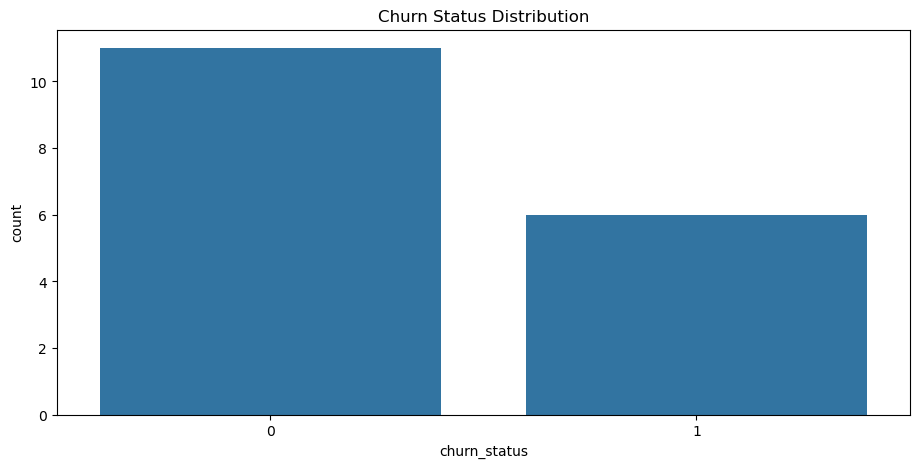

In [112]:
plt.figure(figsize=(11,5))
sns.countplot(data=df_churn_status,x='churn_status')
plt.title('Churn Status Distribution')

Clearly for this dataset the class is imbalanced

In [113]:
df_churn_status['user_rating']

0     4.9
1     4.0
2     4.2
3     3.9
4     2.0
5     3.8
6     4.7
7     4.8
8     2.5
9     1.8
10    4.6
11    2.2
12    5.0
13    4.1
14    2.1
15    2.7
16    3.9
Name: user_rating, dtype: float64

Text(0.5, 1.0, 'User-Rating Distribution')

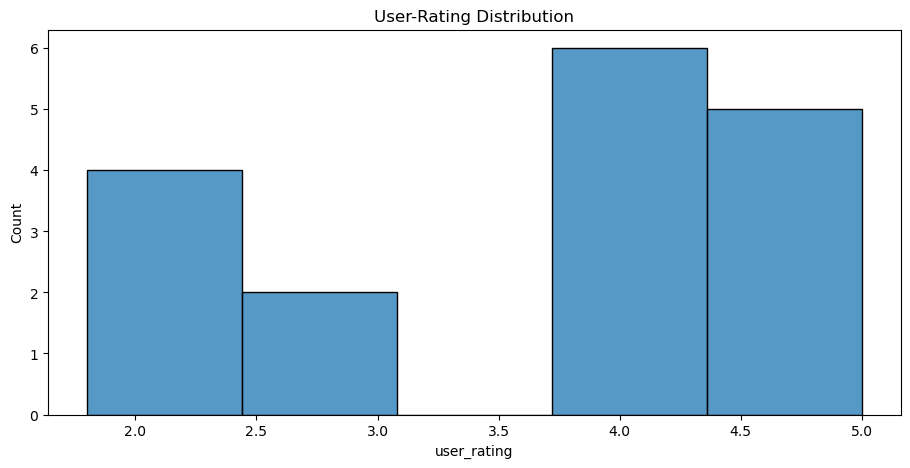

In [114]:
plt.figure(figsize=(11,5))
sns.histplot(data=df_churn_status,x='user_rating',bins=5)
plt.title('User-Rating Distribution')

More Users have given 4+ rating and small amount of users have given rating lesser than 3 

Text(0.5, 1.0, 'User Rating vs Churn status')

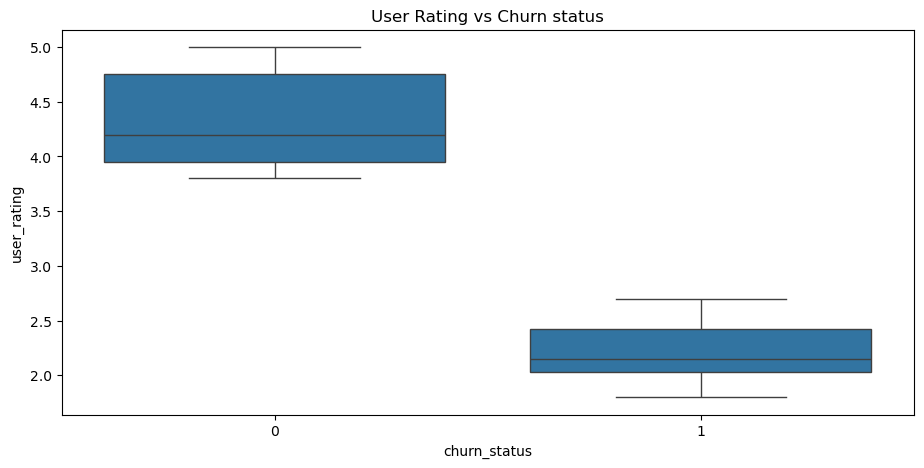

In [115]:
plt.figure(figsize=(11,5))
sns.boxplot(data=df_churn_status,x='churn_status',y='user_rating')
plt.title('User Rating vs Churn status')

The users who havent churned gives rating above than 3.5(they are satisfied with the platform and their features)

# MULTIVARIATE ANALYSIS

In [116]:
user_with_churn=pd.merge(df_users,df_churn_status,on='user_id',how='left')

In [117]:
user_with_churn

,user_id,user_name,contact_info,sign_up_date,subscription_type,country,sign_up_month,churn_status,churn_date,user_rating
0,101,Akhilesh Kumar Shukla,shuklaakhilesh31310@gmail.com,2020-05-03,Annually,India,2020-05,0,NaT,4.9
1,102,John Devis,devisjohn@yahoo.in,2022-06-03,Monthly,USA,2022-06,0,NaT,4.0
2,103,Chen pao,paochen@gmail.com,2024-07-04,Weekly,Japan,2024-07,0,NaT,4.2
3,105,Xi Jingping,jinpingxi@yahoo.in,2023-04-04,Monthly,China,2023-04,0,NaT,3.9
4,106,Kim Jong Un,kimkimki@gmail.com,2025-02-04,Weekly,North Korea,2025-02,1,2025-05-02,2.0
5,107,Guy Parmelin,parmelin@yahoo.in,2026-01-04,Weekly,Switzerland,2026-01,0,NaT,3.8
6,108,Giorgia Meloni,melody@gmail.com,2022-06-04,Annually,Italy,2022-06,0,NaT,4.7
7,109,Satakshi Anand Srivastava,satakshianand28@gmail.com,2022-03-28,Monthly,India,2022-03,0,NaT,4.8
8,110,Aman,aman@yahoo.in,2024-04-04,Annually,India,2024-04,1,2024-10-01,2.5
9,111,Rohan,rohan@gmail.com,2026-04-04,Weekly,India,2026-04,1,2026-05-01,1.8


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'China'),
  Text(1, 0, 'India'),
  Text(2, 0, 'Italy'),
  Text(3, 0, 'Japan'),
  Text(4, 0, 'North Korea'),
  Text(5, 0, 'Switzerland'),
  Text(6, 0, 'USA')])

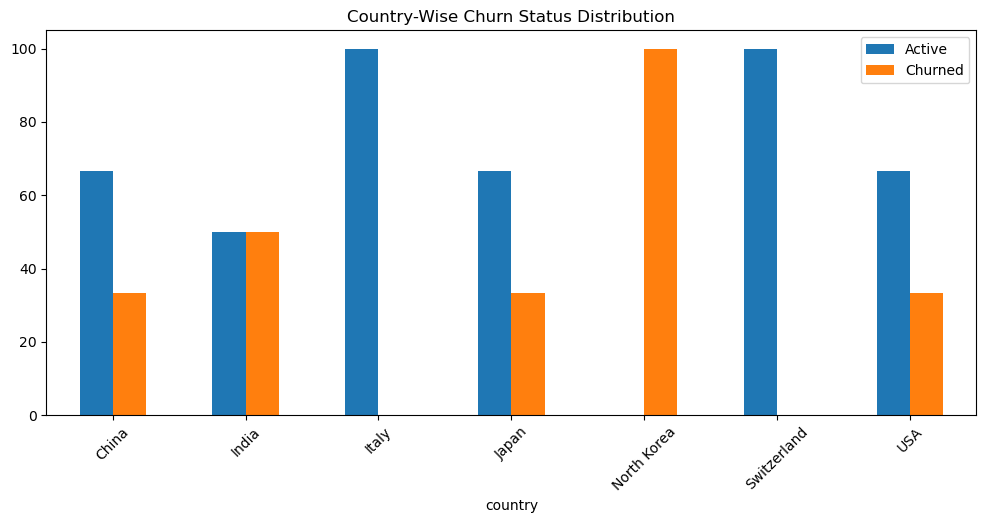

In [123]:
country_churn=pd.crosstab(user_with_churn['country'],user_with_churn['churn_status'],normalize='index')*100

country_churn.columns=['Active','Churned']
country_churn.plot(kind='bar',figsize=(12,5))
plt.title('Country-Wise Churn Status Distribution')
plt.xticks(rotation=45)

Within this sample, North Korea exhibited the highest churn rate (100%). However, this observation is based on a very small number of users and should be interpreted cautiously.

1. Italy,Switzerland has the highest percentage of active users(100%)
2. India showed the churned rate of 50%
3. USA,China and Japan has churned rate of about 30%

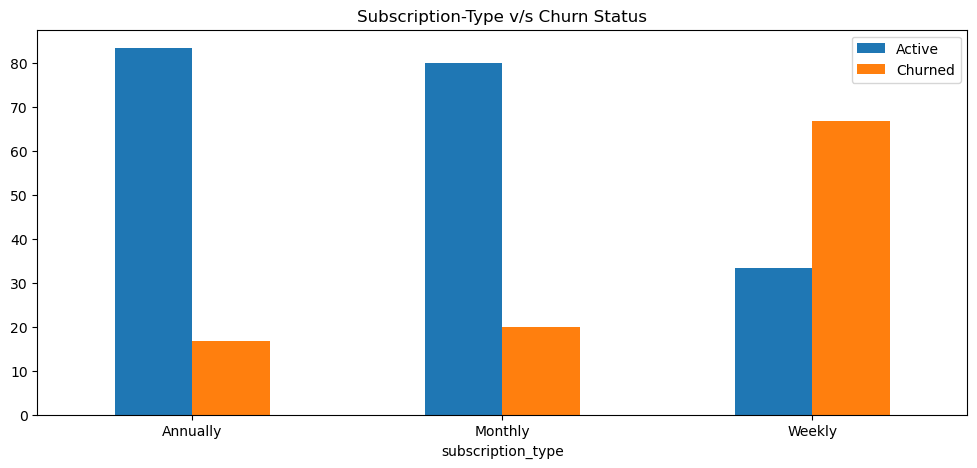

In [136]:
subscription_churn=pd.crosstab(user_with_churn['subscription_type'],user_with_churn['churn_status'],normalize='index')*100

subscription_churn.columns=['Active','Churned']
subscription_churn.plot(kind='bar',figsize=(12,5))
plt.title('Subscription-Type v/s Churn Status')
plt.xticks(rotation=0)
plt.show()

1. Annual Subscription Type exhibited the highest active rate(80%),followed by Monthly Subscription Type having active rate ~78%
2. Weekly subscription type has the highest churned rate(~65%)

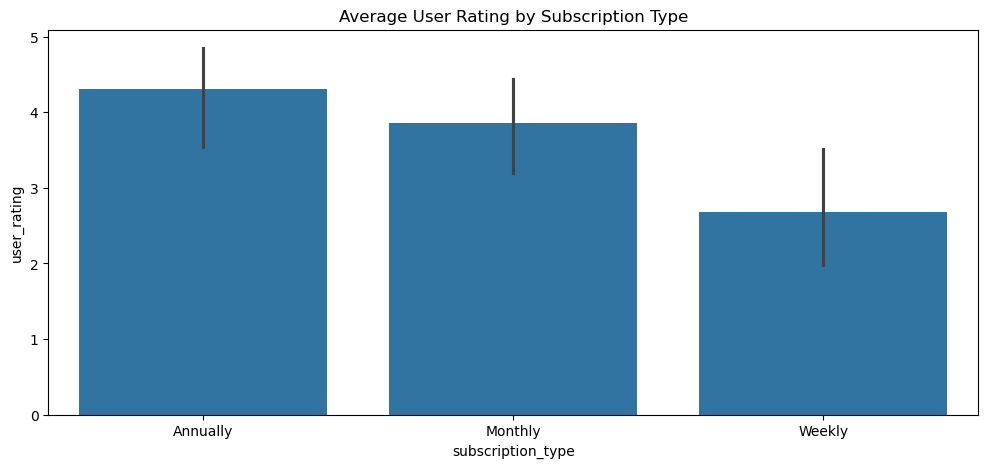

In [139]:
plt.figure(figsize=(12,5))

sns.barplot(data=user_with_churn,x='subscription_type',y='user_rating')
plt.title('Average User Rating by Subscription Type')
plt.show()

1. Within this current sample,Annual Subscription users are more satsified with the platform having average user rating above 4.0,followed by monthly having average rating of about 3.9
2. Weekly Subscription users have average rating of about 2.9

In [141]:
df_churn_status.columns

Index(['user_id', 'churn_status', 'churn_date', 'user_rating'], dtype='object')

In [142]:
df_subscription.columns

Index(['subscription_id', 'user_id', 'subscription_time', 'plan_name',
       'amount', 'month'],
      dtype='object')

In [143]:
subscription_churn=pd.merge(df_subscription,df_churn_status,on='user_id',how='left')

In [144]:
subscription_churn

,subscription_id,user_id,subscription_time,plan_name,amount,month,churn_status,churn_date,user_rating
0,1,101,2020-05-03 09:00:00,Premium,999,2020-05,0,NaT,4.9
1,2,102,2022-06-03 10:30:00,Basic,199,2022-06,0,NaT,4.0
2,3,103,2024-07-04 12:00:00,Weekly,99,2024-07,0,NaT,4.2
3,4,105,2023-04-04 11:00:00,Basic,199,2023-04,0,NaT,3.9
4,5,106,2025-02-04 08:30:00,Weekly,99,2025-02,1,2025-05-02,2.0
5,6,107,2026-01-04 09:30:00,Weekly,99,2026-01,0,NaT,3.8
6,7,108,2022-06-04 10:00:00,Premium,999,2022-06,0,NaT,4.7
7,8,109,2022-03-28 13:30:00,Basic,199,2022-03,0,NaT,4.8
8,9,110,2024-04-04 09:00:00,Premium,999,2024-04,1,2024-10-01,2.5
9,10,111,2026-04-04 10:00:00,Weekly,99,2026-04,1,2026-05-01,1.8


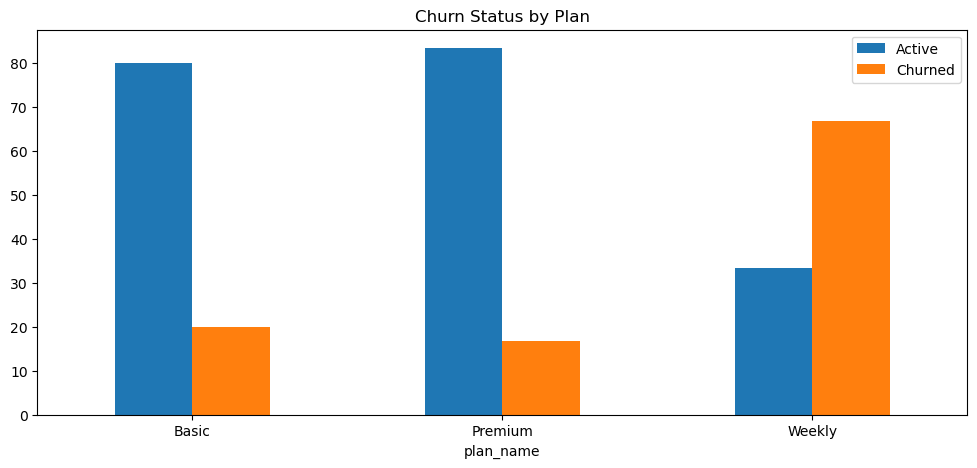

In [145]:
plan_name_churn=pd.crosstab(subscription_churn['plan_name'],subscription_churn['churn_status'],normalize='index')*100
plan_name_churn.columns=['Active','Churned']

plan_name_churn.plot(kind='bar',figsize=(12,5))
plt.title('Churn Status by Plan')
plt.xticks(rotation=0)
plt.show()

Within this Sample, we can conclude the following:
1. Premium plan users has the highest active rate(~85%) followed by Basic plan users who is having active rate of about 80%.
2. Weekly plan users has the lowest active rate(~35%) and the highest churned rate(~65%)

Text(0.5, 1.0, 'Average Rating by Plan')

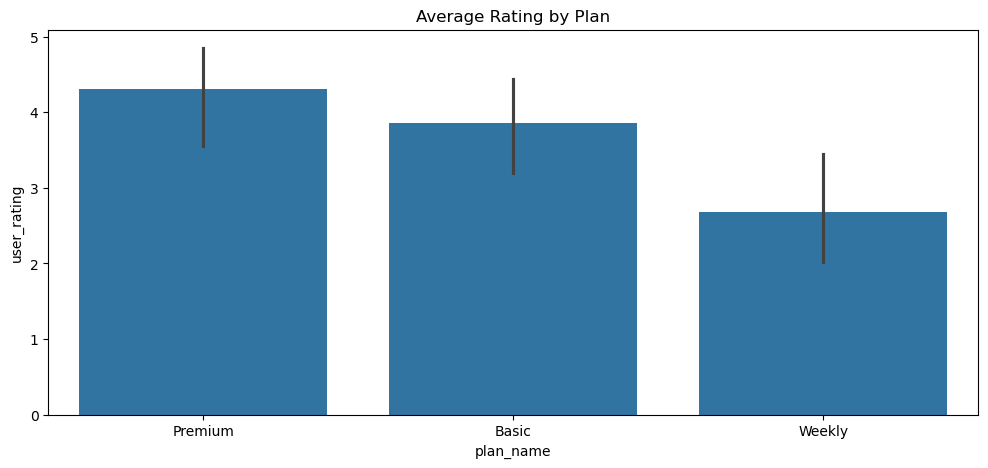

In [147]:
plt.figure(figsize=(12,5))
sns.barplot(data=subscription_churn,x='plan_name',y='user_rating')
plt.title('Average Rating by Plan')

Within the current sample:
1. Premium and Basic exhibited more average rating than weekly
2. Weekly tends to have less average rating(~2.7)

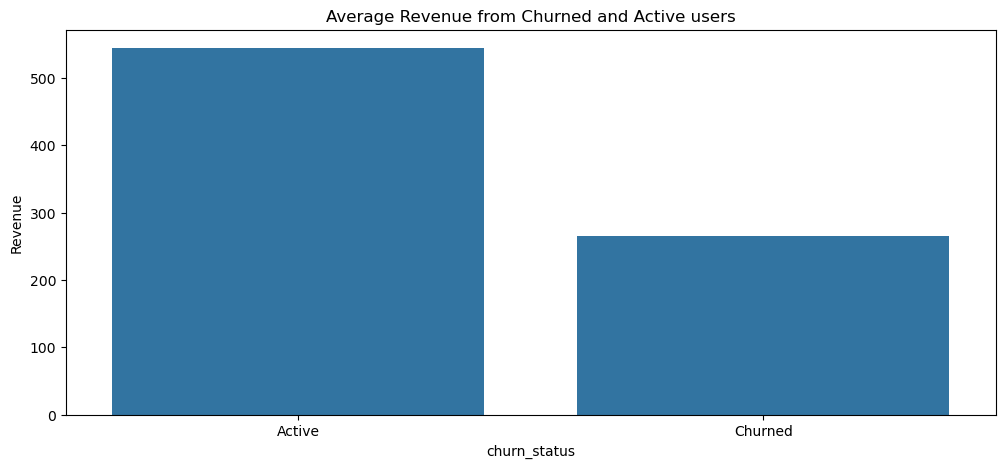

In [186]:
revenue_plan_churn=subscription_churn.groupby('churn_status')['amount'].mean().reset_index(name='Revenue')

plt.figure(figsize=(12,5))
sns.barplot(data=revenue_plan_churn,x='churn_status',y='Revenue')
plt.title('Average Revenue from Churned and Active users')
plt.xticks(ticks=[0,1],labels=['Active','Churned'])
plt.show()

Within the current sample, we can conclude the following:
1. Platform tend to earn more from Active user
2. Churned users accumalated less average revenue than Active users

In [154]:
session_metrics=(df_sessions.groupby('user_id').agg(
    Total_Session_Duration=('session_duration','sum'),
    Avg_Session_Duration=('session_duration','mean'),
    Login_Frequency=('session_id','count')).reset_index())

In [155]:
df_sessions

,session_id,user_id,log_in_time,log_out_time,session_duration
0,1,101,2026-05-20 09:00:00,2026-05-20 11:00:00,120.0
1,2,101,2026-05-21 10:00:00,2026-05-21 12:30:00,150.0
2,3,108,2026-05-20 08:00:00,2026-05-20 10:30:00,150.0
3,4,109,2026-05-21 09:30:00,2026-05-21 11:00:00,90.0
4,5,112,2026-05-22 07:00:00,2026-05-22 09:00:00,120.0
5,6,114,2026-05-22 08:30:00,2026-05-22 12:00:00,210.0
6,7,106,2025-04-01 10:00:00,2025-04-01 10:15:00,15.0
7,8,110,2024-09-20 09:00:00,2024-09-20 09:10:00,10.0
8,9,111,2026-04-28 08:00:00,2026-04-28 08:05:00,5.0
9,10,113,2026-05-10 12:00:00,2026-05-10 12:08:00,8.0


In [156]:
session_churn=pd.merge(session_metrics,df_churn_status,on='user_id',how='left')

In [157]:
session_churn

,user_id,Total_Session_Duration,Avg_Session_Duration,Login_Frequency,churn_status,churn_date,user_rating
0,101,270.0,135.0,2,0,NaT,4.9
1,106,15.0,15.0,1,1,2025-05-02,2.0
2,108,150.0,150.0,1,0,NaT,4.7
3,109,90.0,90.0,1,0,NaT,4.8
4,110,10.0,10.0,1,1,2024-10-01,2.5
5,111,5.0,5.0,1,1,2026-05-01,1.8
6,112,120.0,120.0,1,0,NaT,4.6
7,113,8.0,8.0,1,1,2026-05-20,2.2
8,114,210.0,210.0,1,0,NaT,5.0
9,116,12.0,12.0,1,1,2021-02-02,2.1


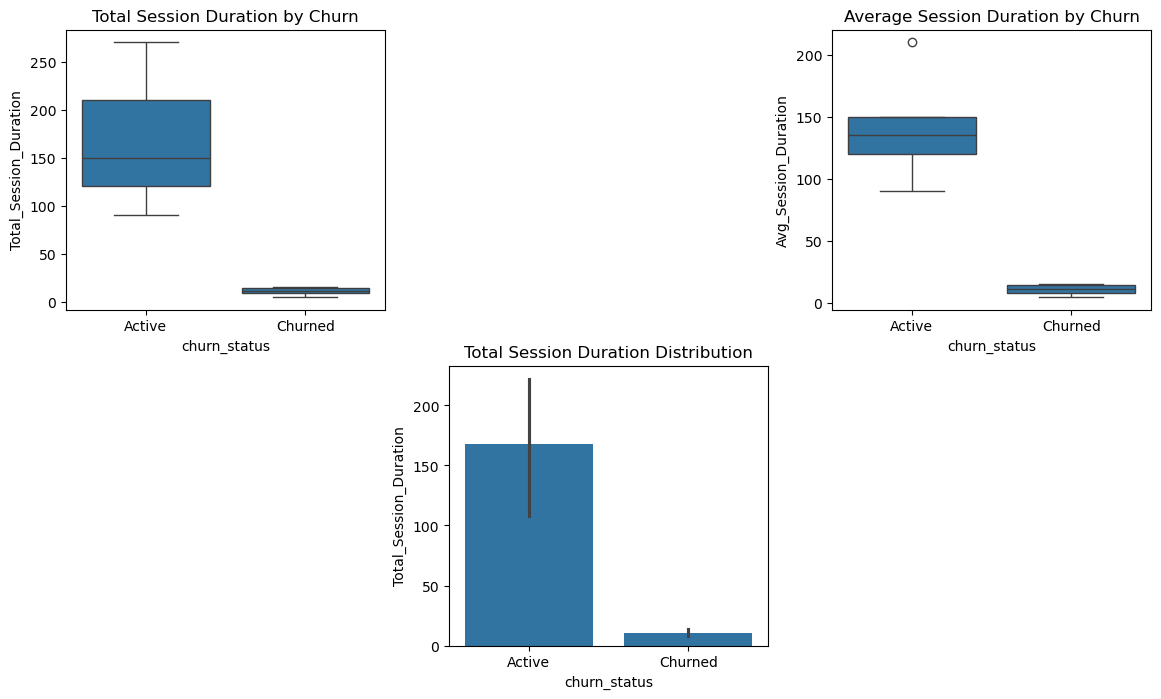

In [166]:
plt.figure(figsize=(14,8))

plt.subplot(2,3,1)
sns.boxplot(data=session_churn,x='churn_status',y='Total_Session_Duration')
plt.title('Total Session Duration by Churn')
plt.xticks(ticks=['0','1'],labels=['Active','Churned'])

plt.subplot(2,3,3)
sns.boxplot(data=session_churn,x='churn_status',y='Avg_Session_Duration')
plt.title('Average Session Duration by Churn')
plt.xticks(ticks=['0','1'],labels=['Active','Churned'])

plt.subplot(2,3,5)
sns.barplot(data=session_churn,x='churn_status',y='Total_Session_Duration')
plt.title('Total Session Duration Distribution')
plt.xticks(ticks=['0','1'],labels=['Active','Churned'])
plt.show()

Using the current dataset, we can conclude the following:
1. Active users exhibit more session duration then churned users
2. Churned users exhibit session duration lesser than 50 mins

In [167]:
feature_data

,usage_id,feature_id,user_id,usage_time,feature_name,feature_date_time
0,1,10,101,2026-06-04 09:20:00,Daily Streaks,2023-07-02 16:30:00.000
1,2,1,101,2026-06-04 10:15:00,AI Assistant,2022-03-12 14:30:00.000
2,3,11,101,2026-06-04 10:40:00,Create Notes,2022-04-03 11:00:00.000
3,4,10,108,2026-06-04 08:45:00,Daily Streaks,2023-07-02 16:30:00.000
4,5,3,108,2026-06-04 09:10:00,AI Test Paper Analyzer,2024-03-03 16:30:00.000
5,6,1,109,2026-06-04 10:00:00,AI Assistant,2022-03-12 14:30:00.000
6,7,10,109,2026-06-04 10:45:00,Daily Streaks,2023-07-02 16:30:00.000
7,8,1,112,2026-06-04 07:30:00,AI Assistant,2022-03-12 14:30:00.000
8,9,2,112,2026-06-04 08:20:00,AI Transcript,2023-01-01 00:05:00.000
9,10,10,114,2026-06-04 09:00:00,Daily Streaks,2023-07-02 16:30:00.000


In [168]:
feature_churn=pd.merge(feature_data,df_churn_status,on='user_id',how='left')

In [169]:
feature_churn

,usage_id,feature_id,user_id,usage_time,feature_name,feature_date_time,churn_status,churn_date,user_rating
0,1,10,101,2026-06-04 09:20:00,Daily Streaks,2023-07-02 16:30:00.000,0,NaT,4.9
1,2,1,101,2026-06-04 10:15:00,AI Assistant,2022-03-12 14:30:00.000,0,NaT,4.9
2,3,11,101,2026-06-04 10:40:00,Create Notes,2022-04-03 11:00:00.000,0,NaT,4.9
3,4,10,108,2026-06-04 08:45:00,Daily Streaks,2023-07-02 16:30:00.000,0,NaT,4.7
4,5,3,108,2026-06-04 09:10:00,AI Test Paper Analyzer,2024-03-03 16:30:00.000,0,NaT,4.7
5,6,1,109,2026-06-04 10:00:00,AI Assistant,2022-03-12 14:30:00.000,0,NaT,4.8
6,7,10,109,2026-06-04 10:45:00,Daily Streaks,2023-07-02 16:30:00.000,0,NaT,4.8
7,8,1,112,2026-06-04 07:30:00,AI Assistant,2022-03-12 14:30:00.000,0,NaT,4.6
8,9,2,112,2026-06-04 08:20:00,AI Transcript,2023-01-01 00:05:00.000,0,NaT,4.6
9,10,10,114,2026-06-04 09:00:00,Daily Streaks,2023-07-02 16:30:00.000,0,NaT,5.0


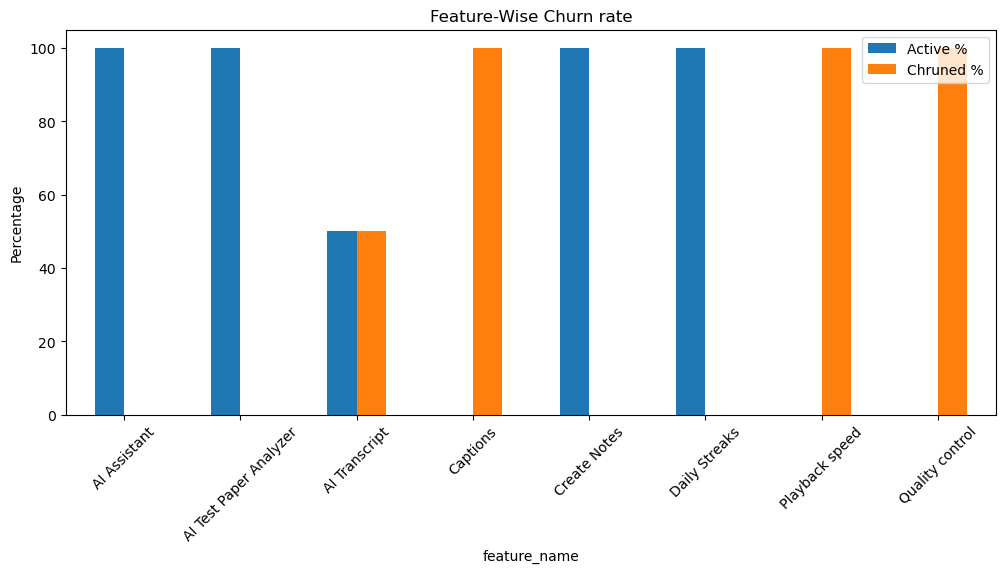

In [174]:
feature_wise_churn=(pd.crosstab(feature_churn['feature_name'],feature_churn['churn_status'],normalize='index')*100)
feature_wise_churn.columns=['Active %','Chruned %']

feature_wise_churn.plot(kind='bar',figsize=(12,5))
plt.title('Feature-Wise Churn rate')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

Using the Current dataset, we can conclude that:
1. AI assistant,AI Test Paper Analyzer,Create Notes and Daily streaks exhibits the active % of 100%.
2. Playback speed,Captions and Quality control have an churn rate of 100%

In [176]:
feature_diversity_churn=pd.merge(feature_used_each_user,df_churn_status,on='user_id')

In [179]:
feature_diversity_churn

,user_id,Num of Uniques features used by users,churn_status,churn_date,user_rating
0,101,3,0,NaT,4.9
1,106,1,1,2025-05-02,2.0
2,108,2,0,NaT,4.7
3,109,2,0,NaT,4.8
4,110,1,1,2024-10-01,2.5
5,111,1,1,2026-05-01,1.8
6,112,2,0,NaT,4.6
7,113,1,1,2026-05-20,2.2
8,114,2,0,NaT,5.0
9,116,1,1,2021-02-02,2.1


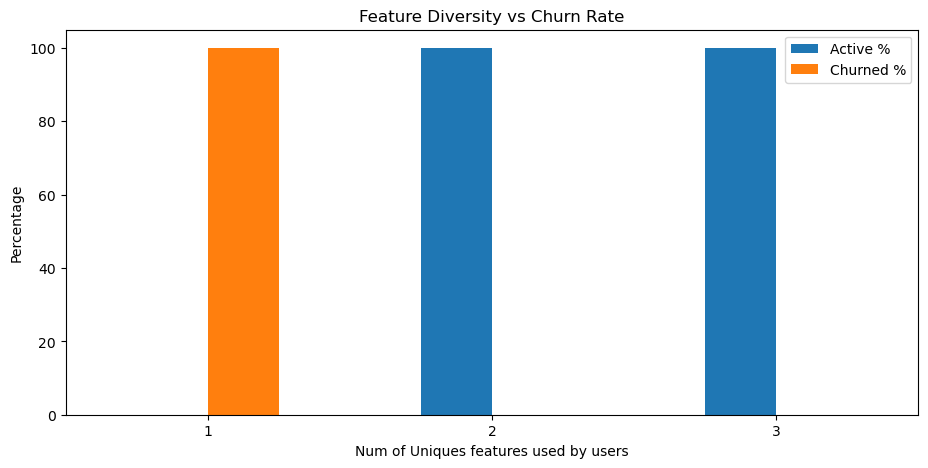

In [185]:
feature_diversity_churn_rate=(pd.crosstab(feature_diversity_churn['Num of Uniques features used by users'],feature_diversity_churn['churn_status'],normalize='index')*100)
feature_diversity_churn_rate.columns=['Active %','Churned %']

feature_diversity_churn_rate.plot(kind='bar',figsize=(11,5))
plt.title('Feature Diversity vs Churn Rate')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

Using the current dataset, we can derive the following conclusion:
1. Users using less than 2 unique feature is having highest churn rate(100%).
2. Active users uses more than 2 unique Features.